# 04 — EEGNet hyperparameter sweep

Imports the exact `EEGNet` class from `eeg_online_classifier.py` so the production architecture is the thing being tuned. Grid search keeps the default set tight — 4-channel / ~90-trial data doesn't support a huge search space without overfitting the CV.

Note: we deliberately disable the aggressive augmentation used in the live trainer (`augment()` in the main script) so the comparison with classical baselines is apples-to-apples on raw data. The best architecture here can be retrained with full augmentation in the summary notebook.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('..'))

import itertools
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

from eeg_online_classifier import EEGNet

from utils.data import load_xdf_epochs
from utils.eval import cv_score, save_result, RESULTS_DIR
from utils.plot import plot_confusion

torch.manual_seed(42); np.random.seed(42)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE)

device: cpu


In [2]:
def train_one(X_tr, y_tr, X_val, y_val, cfg, epochs=120, lr=8e-4, batch=16):
    n_classes = int(max(y_tr.max(), y_val.max())) + 1
    n_ch, n_samp = X_tr.shape[1], X_tr.shape[2]
    model = EEGNet(n_classes=n_classes, n_channels=n_ch, n_samples=n_samp,
                   F1=cfg['F1'], D=cfg['D'], F2=cfg['F1']*cfg['D']*2,
                   kern_len=cfg['kern_len'], dropout=cfg['dropout']).to(DEVICE)

    counts = np.bincount(y_tr, minlength=n_classes).astype(np.float32)
    w = torch.from_numpy((1.0 / (counts + 1e-6)).astype(np.float32)); w /= w.sum()
    criterion = nn.CrossEntropyLoss(weight=w.to(DEVICE))
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=1e-5)

    Xtr_t = torch.tensor(X_tr[:, None, :, :])  # (n, 1, ch, t)
    ytr_t = torch.tensor(y_tr)
    Xv_t  = torch.tensor(X_val[:, None, :, :]).to(DEVICE)
    dl = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=batch, shuffle=True)

    best_state, best_acc = None, -1.0
    for _ in range(epochs):
        model.train()
        for xb, yb in dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            criterion(model(xb), yb).backward()
            opt.step()
        sched.step()
        model.eval()
        with torch.no_grad():
            preds = model(Xv_t).argmax(1).cpu().numpy()
        acc = (preds == y_val).mean()
        if acc > best_acc:
            best_acc = acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    # Restore best weights for final prediction
    model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
    model.eval()
    with torch.no_grad():
        return model(Xv_t).argmax(1).cpu().numpy()

## Window-length comparison

Before sweeping architecture we check whether 2.5 s is optimal. Changing this means changing `WINDOW_SEC` in `eeg_online_classifier.py` + retraining, so only report a different window if the F1 gain is worth that deployment change.

In [3]:
BASE_CFG = dict(F1=4, D=2, kern_len=64, dropout=0.6)

win_rows = []
for win in (2.0, 2.5, 3.0):
    Xw, yw, classes = load_xdf_epochs('../visionpro-ml.xdf', window_sec=win)
    def _fp(X_tr, y_tr, X_val, y_val):
        return train_one(X_tr, y_tr, X_val, y_val, BASE_CFG, epochs=120)
    r = cv_score(_fp, Xw, yw)
    win_rows.append({'window_sec': win, 'n_trials': len(yw),
                     'acc': r['accuracy'], 'f1': r['f1_macro']})
pd.DataFrame(win_rows)

,window_sec,n_trials,acc,f1
0,2.0,90,0.488889,0.420089
1,2.5,90,0.500000,0.493584
2,3.0,90,0.433333,0.346867


## Architecture grid at the 2.5 s deployment window

In [4]:
X, y, classes = load_xdf_epochs('../visionpro-ml.xdf', window_sec=2.5)
print('X:', X.shape, ' y:', y.shape, ' classes:', classes)

grid = list(itertools.product(
    [4, 8],          # F1
    [2],             # D (fixed — keeps spatial depth sane at 4 channels)
    [32, 64],        # kern_len (temporal)
    [0.5, 0.6, 0.7], # dropout
))

rows = []
for F1, D, k, dr in grid:
    cfg = dict(F1=F1, D=D, kern_len=k, dropout=dr)
    def _fp(X_tr, y_tr, X_val, y_val, cfg=cfg):
        return train_one(X_tr, y_tr, X_val, y_val, cfg, epochs=100)
    r = cv_score(_fp, X, y)
    rows.append({**cfg, 'acc': r['accuracy'], 'f1': r['f1_macro'],
                 'f1_std': r['f1_macro_std']})
    print(f"F1={F1} D={D} k={k} dr={dr}: f1={r['f1_macro']:.3f}")
df = pd.DataFrame(rows).sort_values('f1', ascending=False).reset_index(drop=True)
df

X: (90, 4, 625)  y: (90,)  classes: {0: 'left', 1: 'right', 2: 'both'}


F1=4 D=2 k=32 dr=0.5: f1=0.430


F1=4 D=2 k=32 dr=0.6: f1=0.483


F1=4 D=2 k=32 dr=0.7: f1=0.315


F1=4 D=2 k=64 dr=0.5: f1=0.499


...

F1=8 D=2 k=32 dr=0.7: f1=0.435


F1=8 D=2 k=64 dr=0.5: f1=0.510


F1=8 D=2 k=64 dr=0.6: f1=0.402


F1=8 D=2 k=64 dr=0.7: f1=0.396


,F1,D,kern_len,dropout,acc,f1,f1_std
0,8,2,64,0.5,0.544444,0.510466,0.116948
1,4,2,64,0.5,0.511111,0.499447,0.067752
2,8,2,32,0.6,0.522222,0.496320,0.082693
3,4,2,32,0.6,0.500000,0.482695,0.068498
4,8,2,32,0.7,0.511111,0.435263,0.158165
5,4,2,32,0.5,0.466667,0.430274,0.149913
6,8,2,32,0.5,0.455556,0.418289,0.094459
7,4,2,64,0.6,0.477778,0.409978,0.146033
8,8,2,64,0.6,0.466667,0.402456,0.137689
9,8,2,64,0.7,0.444444,0.395613,0.124616


In [5]:
best_cfg = df.iloc[0][['F1', 'D', 'kern_len', 'dropout']].to_dict()
best_cfg = {k: int(v) if k != 'dropout' else float(v) for k, v in best_cfg.items()}
print('best:', best_cfg)

def fp_best(X_tr, y_tr, X_val, y_val):
    return train_one(X_tr, y_tr, X_val, y_val, best_cfg, epochs=200)

result = cv_score(fp_best, X, y, n_splits=5, seed=42)
print(f"final CV: acc={result['accuracy']:.3f} ± {result['accuracy_std']:.3f}  "
      f"f1={result['f1_macro']:.3f} ± {result['f1_macro_std']:.3f}")

best: {'F1': 8, 'D': 2, 'kern_len': 64, 'dropout': 0.5}


final CV: acc=0.500 ± 0.061  f1=0.499 ± 0.063


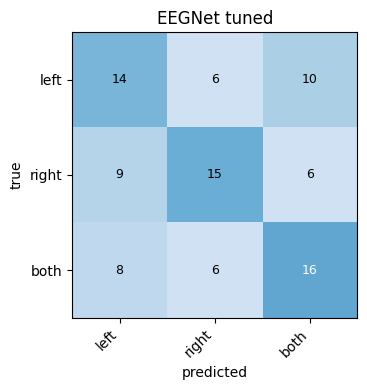

In [6]:
fig, ax = plt.subplots(figsize=(4, 4))
plot_confusion(np.array(result['confusion']), classes, ax=ax, title='EEGNet tuned')
plt.tight_layout(); plt.show()

## Save results + final weights

Checkpoint uses the `{'state_dict', 'classes'}` format expected by `load_model()` in the online classifier.

In [7]:
save_result('04_eegnet_tuned', result, classes)

n_ch, n_samp = X.shape[1], X.shape[2]
final = EEGNet(n_classes=len(classes), n_channels=n_ch, n_samples=n_samp,
               F1=best_cfg['F1'], D=best_cfg['D'],
               F2=best_cfg['F1'] * best_cfg['D'] * 2,
               kern_len=best_cfg['kern_len'], dropout=best_cfg['dropout']).to(DEVICE)

# Retrain on full data using same recipe
_ = train_one(X, y, X, y, best_cfg, epochs=200)  # warm run, discards preds
# Re-train the exported model cleanly on all data
final.load_state_dict({k: v for k, v in
    EEGNet(n_classes=len(classes), n_channels=n_ch, n_samples=n_samp,
           F1=best_cfg['F1'], D=best_cfg['D'],
           F2=best_cfg['F1']*best_cfg['D']*2,
           kern_len=best_cfg['kern_len'], dropout=best_cfg['dropout']).state_dict().items()})

from torch.utils.data import DataLoader, TensorDataset
opt = torch.optim.Adam(final.parameters(), lr=8e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=200, eta_min=1e-5)
counts = np.bincount(y, minlength=len(classes)).astype(np.float32)
w = torch.from_numpy((1.0 / (counts + 1e-6)).astype(np.float32)); w /= w.sum()
crit = nn.CrossEntropyLoss(weight=w.to(DEVICE))
dl = DataLoader(TensorDataset(torch.tensor(X[:, None]), torch.tensor(y)),
                batch_size=16, shuffle=True)
final.train()
for _ in range(200):
    for xb, yb in dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad(); crit(final(xb), yb).backward(); opt.step()
    sched.step()

out = RESULTS_DIR / '04_eegnet_tuned.pt'
torch.save({
    'state_dict': {k: v.detach().cpu() for k, v in final.state_dict().items()},
    'classes': classes,
    'cfg': best_cfg,
    'window_sec': 2.5,
    'channels': [0, 1, 3, 4],
}, out)
print('saved →', out)

saved → /Users/macuser/Downloads/EEG Classifier/notebooks/results/04_eegnet_tuned.pt
